## 6. 인과 모델: 가정과 과제

In [ ]:
#%pip install -U ipywidgets

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

import dowhy
from dowhy import CausalModel

from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from sklearn.ensemble import GradientBoostingRegressor

from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import graphviz

In [2]:
COLORS = [
    '#00B0F0',
    '#FF0000'
]

## 1\. 불충분한 데이터 - 실험

데이터의 양(샘플 크기)과 노이즈 수준이 인과 효과 추정의 정확도에 미치는 영향을 확인하기 위한 시뮬레이션 실험을 설계하고 실행한다.

### 1.1 그래프

In [3]:
# Construct the graph (the graph is constant for all iterations)
# 그래프 구성 (그래프는 모든 반복에 대해 일정함)
nodes = ['S', 'Q', 'X', 'Y', 'P']
edges = ['SQ', 'SY', 'QX', 'QY', 'XP', 'YP', 'XY']

# Generate the GML graph
# GML 그래프 생성
gml_string = 'graph [directed 1\n'

for node in nodes:
    gml_string += f'\tnode [id "{node}" label "{node}"]\n'

for edge in edges:
    gml_string += f'\tedge [source "{edge[0]}" target "{edge[1]}"]\n'

gml_string += ']'

### 1.2 실험

In [4]:
# Define the true effect
# 실제 효과 정의
TRUE_EFFECT = .7

# Define experiment params
# 실험 파라미터 정의
sample_sizes = [30, 100, 1000, 10000]
noise_coefs = [.1, .2, .3, .4, .5, .6, .7, .8]
n_samples = 20

# Record the results
# 결과 기록
results = []

# Run the experiment
# 실험 실행
for sample_size in tqdm(sample_sizes):
    for noise_coef in noise_coefs:
        for i in range(n_samples):

            # Generate the data
            # 데이터 생성
            S = np.random.random(sample_size)
            Q = 0.2*S + noise_coef*np.random.random(sample_size)
            X = 0.14*Q + noise_coef*np.random.random(sample_size)
            Y = TRUE_EFFECT*X + 0.11*Q + 0.32*S + noise_coef*np.random.random(sample_size)
            P = 0.43*X + 0.21*Y + noise_coef*np.random.random(sample_size)

            # Encode as a pandas df
            # pandas df로 인코딩
            df = pd.DataFrame(np.vstack([S, Q, X, Y, P]).T, columns=['S', 'Q', 'X', 'Y', 'P'])

            # Instantiate the CausalModel
            # CausalModel 인스턴스화
            model = CausalModel(
                data=df,
                treatment='X',
                outcome='Y',
                graph=gml_string
            )

            # Get the estimand
            # estimand 얻기
            estimand = model.identify_effect()

            # Get estimate (DML)
            # 추정치 얻기 (DML)
            estimate_dml = model.estimate_effect(
                identified_estimand=estimand,
                method_name='backdoor.econml.dml.DML',
                method_params={
                    'init_params': {
                        'model_y': GradientBoostingRegressor(),
                        'model_t': GradientBoostingRegressor(),
                        'model_final': LassoCV(fit_intercept=False),
                    },
                    'fit_params': {}}
            )

            # Get estimate (Linear Regression)
            # 추정치 얻기 (선형 회귀)
            estimate_lr = model.estimate_effect(
                identified_estimand=estimand,
                method_name='backdoor.linear_regression')

            results.append(
                {
                    'sample_size': sample_size,
                    'noise_coef': noise_coef,
                    'estimate_dml': estimate_dml.value,
                    'estimate_lr': estimate_lr.value,
                    'error_dml': estimate_dml.value - TRUE_EFFECT,
                    'error_lr': estimate_lr.value - TRUE_EFFECT
                }
            )

  0%|          | 0/4 [00:00<?, ?it/s]

In [5]:
results_df = pd.DataFrame(results)
results_df

,sample_size,noise_coef,estimate_dml,estimate_lr,error_dml,error_lr
0,30,0.1,1.011845,1.046957,0.311845,0.346957
1,30,0.1,0.547500,0.572005,-0.152500,-0.127995
2,30,0.1,0.000000,0.320148,-0.700000,-0.379852
3,30,0.1,0.472627,0.614079,-0.227373,-0.085921
4,30,0.1,0.000000,0.569637,-0.700000,-0.130363
...,...,...,...,...,...,...
635,10000,0.8,0.708665,0.711399,0.008665,0.011399
636,10000,0.8,0.692436,0.693563,-0.007564,-0.006437
637,10000,0.8,0.692921,0.696479,-0.007079,-0.003521
638,10000,0.8,0.682477,0.690033,-0.017523,-0.009967


In [ ]:
# Instantiate the CausalModel
# CausalModel 인스턴스화
model = CausalModel(
    data=df,
    treatment='X',
    outcome='Y',
    graph=gml_string
)

In [ ]:
model.view_model()

### 1.2 실험

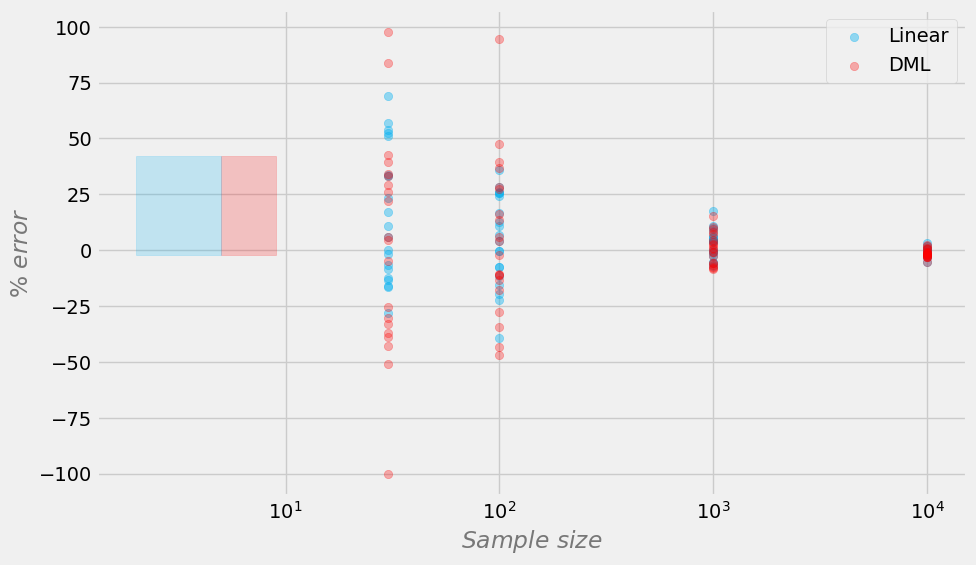

In [6]:
plt.figure(figsize=(10, 6))

plt.fill_betweenx([-2, 42], 5, 9, color=COLORS[1], alpha=.2)
plt.fill_betweenx([-2, 42], 2, 5, color=COLORS[0], alpha=.2)

plt.scatter(
    results_df[results_df['noise_coef'] == .3]['sample_size'],
    (results_df[results_df['noise_coef'] == .3]['error_lr'] / TRUE_EFFECT) * 100,
    color=COLORS[0],
    alpha=.4,
    label='Linear'
)

plt.scatter(
    results_df[results_df['noise_coef'] == .3]['sample_size'],
    (results_df[results_df['noise_coef'] == .3]['error_dml'] / TRUE_EFFECT) * 100,
    color=COLORS[1],
    alpha=.3,
    label='DML'
)
plt.xscale('log')
plt.legend()
plt.xlabel('$Sample$ $size$', alpha=.5)
plt.ylabel('% $error$', alpha=.5)
plt.show()

## 2\. 포지티비티 가정 예시

**포지티비티(Positivity) 가정**, 또는 **공통 지지(Common Support)** 가정은 인과추론의 핵심적인 가정 중 하나이다. 이 가정은 어떤 특성(공변량)을 가진 개체라도 모든 처리(treatment)를 받을 확률이 0보다 커야 함을 의미한다. 즉, 처리 그룹과 통제 그룹 간에 비교 가능한 대상이 존재해야 한다는 것이다. 만약 이 가정이 깨지면, 특정 그룹에 대한 인과 효과를 추정할 수 없게 되어 편향된 결과가 나올 수 있다.

Z(공변량), T(처리)가 Y(결과)에 미치는 영향을 정의하는 헬퍼 함수 `get_y`를 정의한다. Z와 Y의 관계는 비선형적임을 알 수 있다.

In [7]:
# Helpers
# 헬퍼 함수
def get_y(z, t):
    return z + .2 * z**2 + 10*np.sin(z) + 9*t

### 2.1 나쁜 경우

포지티비티 가정이 위배되는 "나쁜 경우(Bad case)"의 데이터를 생성한다.

  * `z_t0`: 처리 그룹(T=0)의 공변량 Z 값을 2와 5 사이에서 균등하게 샘플링한다.
  * `z_t1`: 통제 그룹(T=1)의 공변량 Z 값을 5.2와 9 사이에서 균등하게 샘플링한다.

두 그룹의 Z 값 범위가 전혀 겹치지 않으므로, 공통 지지(common support)가 없어 포지티비티 가정이 명백하게 위배된다.

In [8]:
# Set X values
# X 값 설정
z_t0 = np.random.uniform(2, 5, 30)
z_t1 = np.random.uniform(5.2, 9, 30)

In [9]:
# Compute Y
# Y 계산
y_t0 = get_y(z_t0, 0)
y_t1 = get_y(z_t1, 1)

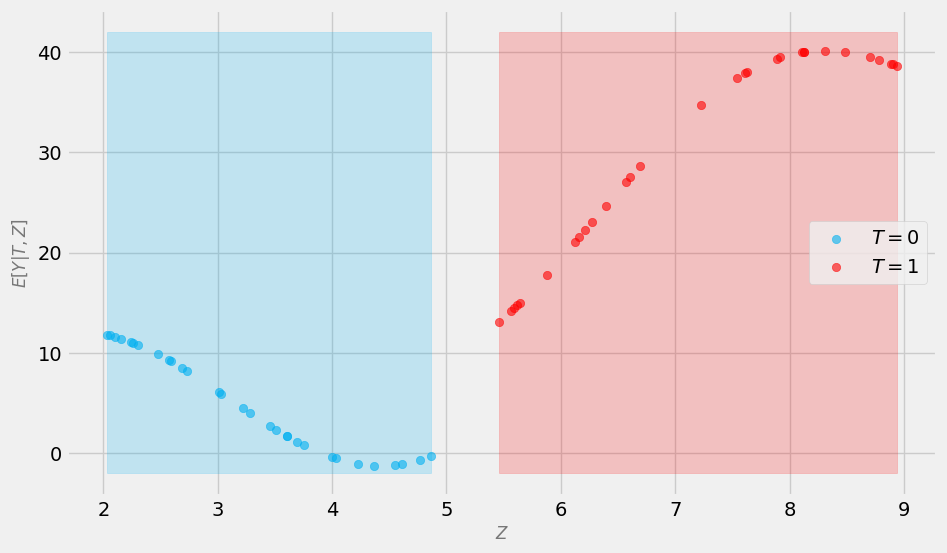

In [10]:
plt.figure(figsize=(10, 6))

plt.fill_betweenx([-2, 42], min(z_t1), max(z_t1), color=COLORS[1], alpha=.2)
plt.fill_betweenx([-2, 42], min(z_t0), max(z_t0), color=COLORS[0], alpha=.2)

plt.scatter(z_t0, y_t0, color=COLORS[0], label='$T=0$', alpha=.6)
plt.scatter(z_t1, y_t1, color=COLORS[1], label='$T=1$', alpha=.6)

plt.xlabel('$Z$', alpha=.5, fontsize=12)
plt.ylabel('$E[Y|T, Z]$', alpha=.5, fontsize=12)

plt.legend()
plt.show()

### 2.2 좋은 경우

포지티비티 가정을 만족하는 "좋은 경우(Good case)"의 데이터를 생성한다. 두 그룹(`z_t0`, `z_t1`) 모두 Z 값을 2와 9 사이의 동일한 범위에서 샘플링하여 두 그룹 간에 공통 지지(overlap)가 존재하도록 한다.

In [11]:
# Set X values
# X 값 설정
z_t0 = np.random.uniform(2, 9, 30)
z_t1 = np.random.uniform(2, 9, 30)

# Compute Y
# Y 계산
y_t0 = get_y(z_t0, 0)
y_t1 = get_y(z_t1, 1)

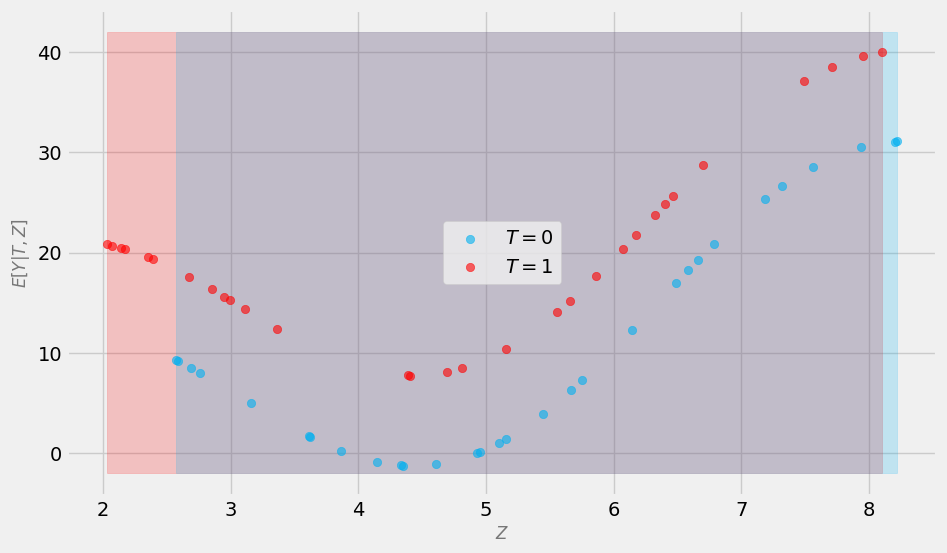

In [12]:
plt.figure(figsize=(10, 6))

plt.fill_betweenx([-2, 42], min(z_t1), max(z_t1), color=COLORS[1], alpha=.2)
plt.fill_betweenx([-2, 42], min(z_t0), max(z_t0), color=COLORS[0], alpha=.2)

plt.scatter(z_t0, y_t0, color=COLORS[0], label='$T=0$', alpha=.6)
plt.scatter(z_t1, y_t1, color=COLORS[1], label='$T=1$', alpha=.6)

plt.xlabel('$Z$', alpha=.5, fontsize=12)
plt.ylabel('$E[Y|T, Z]$', alpha=.5, fontsize=12)

plt.legend()
plt.show()

## 3\. 모듈성

**모듈성(Modularity)** 가정, 또는 **독립 메커니즘(Independent Mechanisms)** 가정은 인과 시스템의 한 부분에 가해진 중재(intervention)가 다른 부분의 인과 메커니즘을 변화시키지 않는다는 가정이다. 예를 들어, 처리 변수 X를 결정하는 방식을 바꾸더라도, X가 결과 Y에 영향을 미치는 방식 자체는 변하지 않아야 한다. 

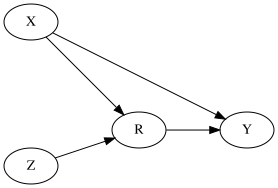

In [13]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['X', 'Y', 'R', 'Z']
positions = ['1,2!', '4,.5!', '2.5,.5!', '1, 0!']

edges = ['XR', 'ZR', 'RY', 'XY']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_08_modularity')

graph

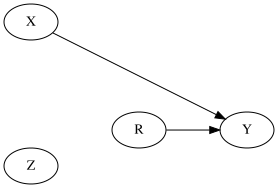

In [14]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['X', 'Y', 'R', 'Z']
positions = ['1,2!', '4,.5!', '2.5,.5!', '1, 0!']

edges = ['RY', 'XY']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_08_modularity_mod')

graph

## 4\. 선택 편향: 사라진 총알 구멍과 에이브러햄 왈드

선택 편향을 설명하기 위한 DAG를 생성한다.

  * T (처리, Treatment): 장갑 보강 여부
  * Y (결과, Outcome): 비행기의 손상 정도
  * C (충돌 변수, Collider): 비행기의 귀환 여부

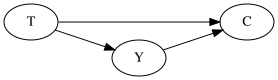

In [15]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['T', 'Y', 'C']
positions = ['0,.5!', '1.5,0!', '3,.5!']

edges = ['TY', 'TC', 'YC']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_08_selection')

graph

In [16]:
SAMPLE_SIZE = 1000

# A hypothetical SCM
# 가상 SCM
T = np.random.uniform(20, 110, SAMPLE_SIZE)
Y = T + np.random.uniform(0, 40, SAMPLE_SIZE)
C = (T + Y < 100).astype('int')

In [17]:
df = pd.DataFrame(np.stack([T, Y, C]).T, columns=['T', 'Y', 'C'])

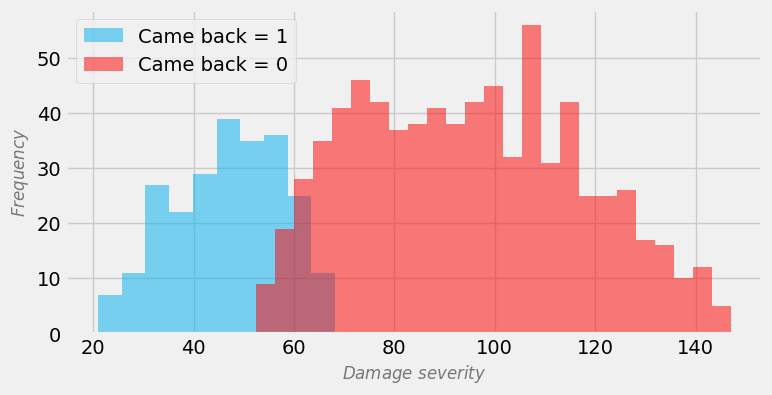

In [18]:
# Compare average damage (biased vs unbiased)
# 평균 손상 비교 (편향 대 비편향)
plt.figure(figsize=(8, 4))

plt.hist(df[df['C'] == 1]['Y'], label='Came back = 1', color=COLORS[0], alpha=.5)
plt.hist(df[df['C'] == 0]['Y'], label='Came back = 0', color=COLORS[1], alpha=.5, bins=25)

plt.xlabel('$Damage$ $severity$', alpha=.5, fontsize=12)
plt.ylabel('$Frequency$', alpha=.5, fontsize=12)

plt.legend()
plt.show()

## 5\. 추가적인 선택 편향

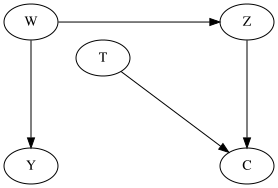

In [19]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['T', 'Y', 'C', 'Z', 'W']
positions = ['1.,1.5!', '0,0!', '3,0!', '3,2!', '0,2!']

edges = ['ZC', 'TC', 'WZ', 'WY']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_08_selection_02')

graph

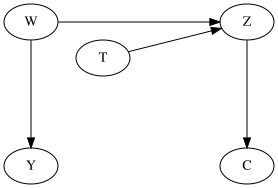

In [20]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['T', 'Y', 'C', 'Z', 'W']
positions = ['1.,1.5!', '0,0!', '3,0!', '3,2!', '0,2!']

edges = ['TZ', 'ZC', 'WZ', 'WY']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_08_selection_03')

graph